<a href="https://colab.research.google.com/github/VidhyaSri-48/Data-Science-Project/blob/masteer/Titanic_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Data Collection

In [4]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
import math

titanic = pd.read_csv('/content/drive/MyDrive/titanic_data.csv')
titanic.head(10)


,survived,pclass,name,sex,age,fare,sibsp,parch
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,1,0
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,0,0
5,0,1,"McCarthy, Mr. Timothy J",male,54.0,51.8625,0,0
6,0,3,"Palsson, Master. Gosta Leonard",male,2.0,21.0750,3,1
7,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,11.1333,0,2
8,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,30.0708,1,0
9,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,16.7000,1,1


In [5]:
print("Number of passengerrs: "+str(len(titanic.index)))  #cal total number of rows

Number of passengerrs: 714


<Axes: xlabel='survived', ylabel='count'>

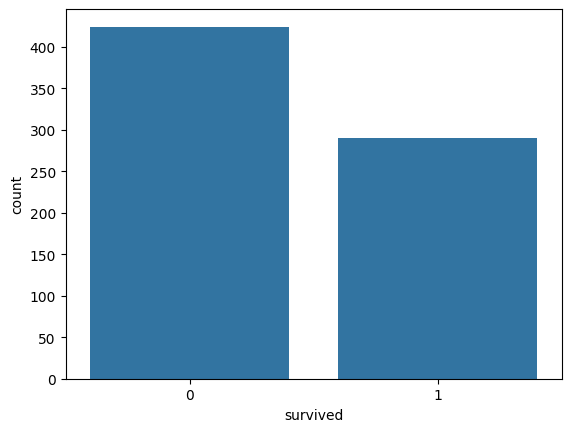

In [9]:
## Analysing data
sns.countplot(x = 'survived', data = titanic)
# countplot - >how many times each category appears



<Axes: xlabel='survived', ylabel='count'>

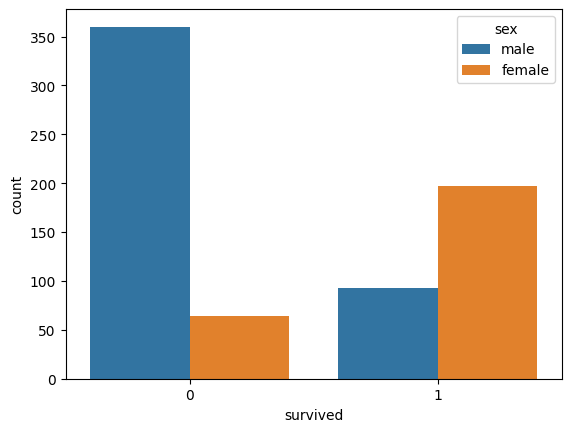

In [10]:
sns.countplot(x = 'survived', hue = "sex", data = titanic)
# hue - > make diiferntiate categories, visually group data points by color

<Axes: xlabel='survived', ylabel='count'>

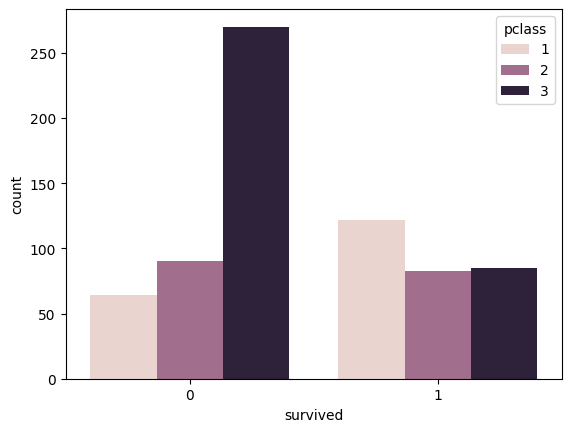

In [11]:
sns.countplot(x = 'survived', hue = "pclass", data = titanic)

<Axes: ylabel='Frequency'>

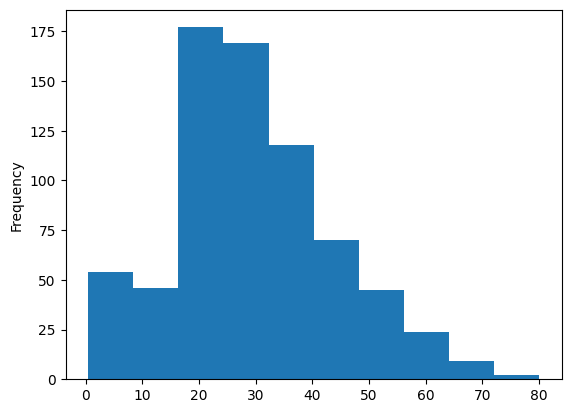

In [21]:
titanic['age'].plot.hist()
# sns.swarmplot(x = titanic['age'])
# sns.histplot(titanic['age'], kde = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   name      714 non-null    object 
 3   sex       714 non-null    object 
 4   age       714 non-null    float64
 5   fare      714 non-null    float64
 6   sibsp     714 non-null    int64  
 7   parch     714 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 44.8+ KB


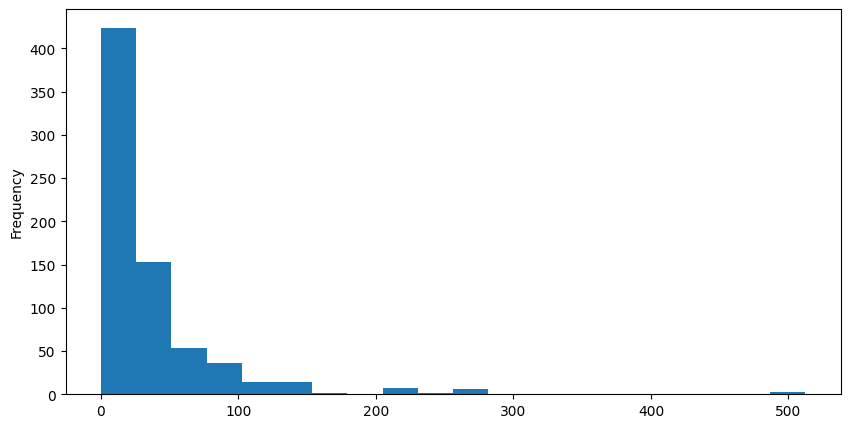

In [25]:
titanic['fare'].plot.hist(bins = 20, figsize = (10,5))
titanic.info() # dislays structure of data frame like
# no of rows, column names, data type of each column, non-nulll counts per column, memory usage

In [1]:
titanic.describe()

NameError: name 'titanic' is not defined

<Axes: xlabel='sibsp', ylabel='count'>

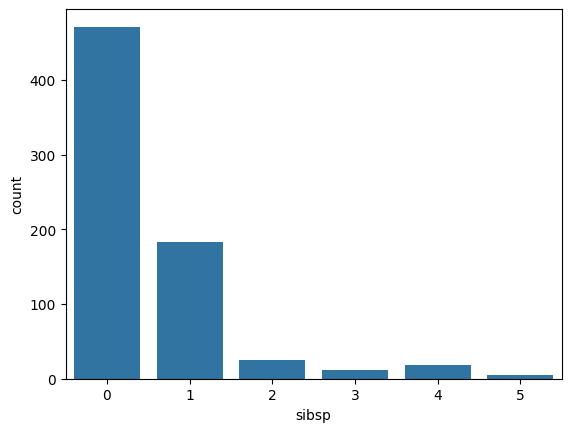

In [26]:
sns.countplot(x = 'sibsp', data = titanic)

In [30]:
#Data Wrangling/ Cleaning
titanic.isnull()
# return true if it is null value

,survived,pclass,name,sex,age,fare,sibsp,parch
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
709,False,False,False,False,False,False,False,False
710,False,False,False,False,False,False,False,False
711,False,False,False,False,False,False,False,False
712,False,False,False,False,False,False,False,False


In [32]:
titanic.isnull().sum()
# check each column has nul value

,0
survived,0
pclass,0
name,0
sex,0
age,0
fare,0
sibsp,0
parch,0


<Axes: >

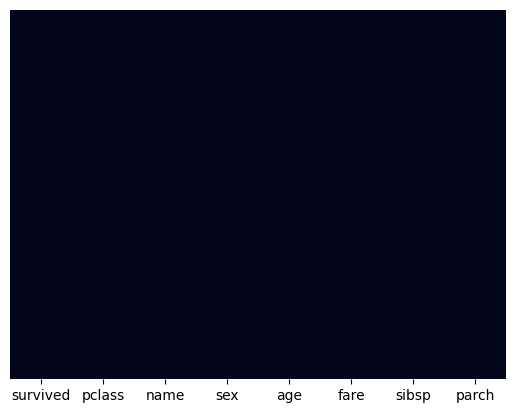

In [40]:
sns.heatmap(titanic.isnull(), yticklabels =False, cbar = False)
# visulaize missing value, cbar hides color bar
# output shows as no marks in plot - > no null value

In [53]:
titanic.dropna(inplace = True)
#dropna() is used to deop column that contain null value, to delete ertain columnn, use drop() alone
titanic.head()

,survived,pclass,sex,age,fare,sibsp,parch
0,0,3,male,22.0,7.2500,1,0
1,1,1,female,38.0,71.2833,1,0
2,1,3,female,26.0,7.9250,0,0
3,1,1,female,35.0,53.1000,1,0
4,0,3,male,35.0,8.0500,0,0


In [45]:
#using string we cannot do anything , can't predict
pd.get_dummies(titanic['sex'] , drop_first = True)
#get_dumies is built in function -> convert categorial data into numberical data,
#as ml can't handle string format

#drop_first drop given first columnu

,male
0,True
1,False
2,False
3,False
4,True
...,...
709,False
710,True
711,False
712,True


In [57]:
titanic.drop('name',axis =1, inplace = True) #axix 1 = column
#already detected, if again access errror

KeyError: "['name'] not found in axis"

In [59]:
titanic.head()  ->3.25
# print(titanic.columns)

,survived,pclass,sex,age,fare,sibsp,parch
0,0,3,male,22.0,7.2500,1,0
1,1,1,female,38.0,71.2833,1,0
2,1,3,female,26.0,7.9250,0,0
3,1,1,female,35.0,53.1000,1,0
4,0,3,male,35.0,8.0500,0,0


In [5]:
from sklearn.tree import DecisionTreeClassifier

# Encode: High=2, Medium=1, Low=0 | Good=1, Bad=0
X = [
    [2, 1],  # High income, Good credit
    [2, 0],  # High income, Bad credit
    [0, 1],  # Low income, Good credit
    [1, 1],  # Medium income, Good credit
    [0, 0],  # Low income, Bad credit
    [1, 0],  # Medium income, Bad credit
]

# Labels: Yes = 1, No = 0
y = [1, 0, 0, 1, 0, 1]

# Train Decision Tree
model = DecisionTreeClassifier()
model.fit(X, y)

# Predict: Medium income, Good credit
prediction = model.predict([[1, 1]])
print("Loan Approved:" , "Yes" if prediction[0] == 1 else "No")


Loan Approved: Yes
